In [1]:
import pandas as pd
import numpy as np
from sklearn.svm import SVC, SVR
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.metrics import accuracy_score, precision_score, recall_score, mean_squared_error, r2_score, f1_score
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report
from runs import multi_subject_experiments, test_experiments
import os
import pickle as pkl
from utils_multisubject import read_files, apply_features, create_window_df

In [2]:
# Source Folders
source_folder = "/Users/juliasantaniello/Desktop/fNIRS-2-RL/Experiment/ParticipantData/fNIRS/LabeledData"

# Channels Used
channels = ["L_O_DSphi", "L_D_DSphi", "R_D_DSphi", "R_O_DSphi",	"L_O_DSI",	"R_D_DSI",	"R_O_DSI",	"L_D_DSI"]

# Features To Remove
remove_features = []

# Label Mapping
labels_for_windows = ["discrete_optimal", "binary_optimal", "continuous_optimal"]
final_labels = {"discrete": "discrete_label",
            "binary": "binary_label",
            "continuous": "continuous_label"}

In [3]:
# Chosen Experiment from runs.py
experiment_number = 5

# Save Model Metrics
save_results = False

# Load Windowed Data
seconds = 7 # Duration of each window in seconds
window_size = int(seconds*5.25)
windowedData = []

# Load Training List and Conditions from runs.py
participant_list, conditions_list, experiment_name = multi_subject_experiments[experiment_number].values()

participants = str(participant_list)
conditions = str(conditions_list)[2:-2]

print("Experiment Name: ", experiment_name)
print("\nTraining List: ", participants, "\nTraining Conditions: ", conditions) 

Experiment Name:  multiSubject

Training List:  [2, 5, 6, 9, 10, 11, 13, 15, 16, 17, 18, 19, 20, 24] 
Training Conditions:  RW


In [4]:
# Remove Random Participants for Cross-Validation
number_of_participants = len(participant_list)

number_of_participants_for_validation = number_of_participants // 5

random_indices = np.random.choice(number_of_participants, 
                                   number_of_participants_for_validation,
                                   replace=False)

train_participants = [participant_list[i] for i in range(number_of_participants) if i not in random_indices]
validation_participants = [participant_list[i] for i in random_indices]

print("Validation Participants: ", validation_participants)
print("Training Participants: ", train_participants)


Validation Participants:  [15, 10]
Training Participants:  [2, 5, 6, 9, 11, 13, 16, 17, 18, 19, 20, 24]


In [ ]:
# Read Files for Training Data
train_data = read_files(participant_list=train_participants, source_folder_1 = source_folder, conditions=conditions_list)
val_data = read_files(participant_list=validation_participants, source_folder_1 = source_folder, conditions=conditions_list)

df_data_train = pd.DataFrame()
df_labels_train = pd.DataFrame()

for key in train_data.keys():
    window_data, window_labels = create_window_df(train_data[key], window_size=window_size, step_size=1, labels=labels_for_windows, features=channels)
    print(key, "is done")
    df_data_train = pd.concat([df_data_train, window_data], ignore_index=True)
    df_labels_train = pd.concat([df_labels_train, window_labels], ignore_index=True)

df_data_train.drop(columns=["start_timestamp", "end_timestamp", "pid", "condition"], inplace=True)

['discrete_optimal', 'binary_optimal', 'continuous_optimal']
2RW is done
['discrete_optimal', 'binary_optimal', 'continuous_optimal']
11RW is done
['discrete_optimal', 'binary_optimal', 'continuous_optimal']
17RW is done
['discrete_optimal', 'binary_optimal', 'continuous_optimal']
24RW is done
['discrete_optimal', 'binary_optimal', 'continuous_optimal']
19RW is done
['discrete_optimal', 'binary_optimal', 'continuous_optimal']
9RW is done
['discrete_optimal', 'binary_optimal', 'continuous_optimal']
5RW is done
['discrete_optimal', 'binary_optimal', 'continuous_optimal']
18RW is done
['discrete_optimal', 'binary_optimal', 'continuous_optimal']
16RW is done
['discrete_optimal', 'binary_optimal', 'continuous_optimal']
6RW is done
['discrete_optimal', 'binary_optimal', 'continuous_optimal']
20RW is done
['discrete_optimal', 'binary_optimal', 'continuous_optimal']
13RW is done


TypeError: 'builtin_function_or_method' object is not iterable

In [120]:
df_data_val = pd.DataFrame()
df_labels_val = pd.DataFrame()

for key in val_data.keys():
    window_data, window_labels = create_window_df(val_data[key], window_size=window_size, step_size=1, labels=labels_for_windows, features=channels)
    print(key, "is done")
    df_data_val = pd.concat([df_data_val, window_data], ignore_index=True)
    df_labels_val = pd.concat([df_labels_val, window_labels], ignore_index=True)

df_data_val.drop(columns=["start_timestamp", "end_timestamp"], inplace=True)
print(df_labels_val.columns)

['discrete_optimal', 'binary_optimal', 'continuous_optimal']
15RW is done
['discrete_optimal', 'binary_optimal', 'continuous_optimal']
10RW is done
Index(['discrete_label', 'continuous_label', 'binary_label'], dtype='object')


In [ ]:
print(df_labels_train["binary_label"].value_counts())
print(df_labels_train["discrete_label"].value_counts())

def create_train_data(df_data, df_labels):
    df = pd.concat([df_data.reset_index(drop=True), df_labels.reset_index(drop=True)], axis=1)

    # Downsample discrete/multi-class labels
    min_discrete = df['discrete_label'].value_counts().min()
    print("Minimum count for discrete_label:", min_discrete)
    df_balanced_discrete = df.groupby('discrete_label', group_keys=False).apply(lambda x: x.sample(min_discrete, random_state=42))

    # Downsample binary labels
    min_binary = df['binary_label'].value_counts().min()
    print("Minimum count for binary_label:", min_binary)
    df_balanced_binary = df.groupby('binary_label', group_keys=False).apply(lambda x: x.sample(min_binary, random_state=42))

    # Separate features and labels
    X_binary = df_balanced_binary[df_data.columns]
    X_discrete = df_balanced_discrete[df_data.columns]
    y_discrete = df_balanced_discrete['discrete_label']
    y_binary = df_balanced_binary['binary_label']
    y_continuous = df['continuous_label']

    return df, X_binary, X_discrete, y_binary, y_discrete, y_continuous

x_continuous, x_binary, x_discrete, y_binary, y_discrete, y_continuous = create_train_data(df_data=df_data_train, df_labels=df_labels_train)
print("Binary label counts:\n", y_binary.value_counts())
print("Discrete label counts:\n", y_discrete.value_counts())

binary_label
1    5611
0    5327
Name: count, dtype: int64
discrete_label
0    5327
1    3542
2    2069
Name: count, dtype: int64
Minimum count for discrete_label: 2069
Minimum count for binary_label: 5327
Binary label counts:
 binary_label
0    5327
1    5327
Name: count, dtype: int64
Discrete label counts:
 discrete_label
0    2069
1    2069
2    2069
Name: count, dtype: int64


In [ ]:
random_state = 42
shuffle = True

test_size = 0.2

X_binary_train, X_binary_test, y_binary_train, y_binary_test = train_test_split(x_binary, y_binary, test_size=test_size, random_state=random_state, shuffle=shuffle, stratify=y_binary)
X_discrete_train, X_discrete_test, y_discrete_train, y_discrete_test = train_test_split(x_discrete, y_discrete, test_size=test_size, random_state=random_state, shuffle=shuffle, stratify=y_discrete)
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(x_continuous, y_continuous, test_size=test_size, random_state=42)

print(y_binary_train.value_counts(), y_binary_test.value_counts())
print(y_discrete_train.value_counts(), y_discrete_test.value_counts())

# Remove chosen features
cols_to_keep = [col for col in X_binary_train.columns if ("skewness" in col.lower())]
X_binary_train = X_binary_train[cols_to_keep]
X_binary_test = X_binary_test[cols_to_keep]
x_validation_train = df_data_val[cols_to_keep]

y_binary_training = y_binary_train.reset_index(drop=True)
y_binary_test = y_binary_test.reset_index(drop=True)

binary_label
1    3729
0    3728
Name: count, dtype: int64 binary_label
0    1599
1    1598
Name: count, dtype: int64
discrete_label
2    1448
1    1448
0    1448
Name: count, dtype: int64 discrete_label
0    621
2    621
1    621
Name: count, dtype: int64


In [ ]:
X_binary_train

NameError: name 'y_binary_training' is not defined

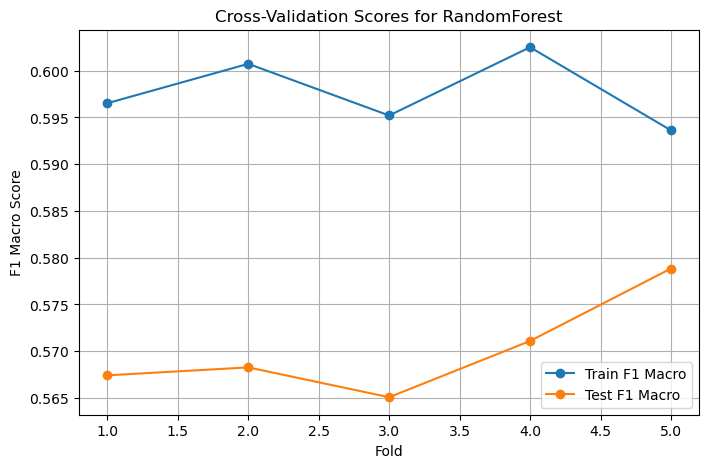

              precision    recall  f1-score   support

           0       0.55      0.74      0.63      1599
           1       0.60      0.39      0.48      1598

    accuracy                           0.57      3197
   macro avg       0.57      0.57      0.55      3197
weighted avg       0.57      0.57      0.55      3197



In [ ]:
from sklearn.model_selection import cross_validate
from sklearn.utils import shuffle

shuffle_test = True
save_binary_results = False

clf = DecisionTreeClassifier(max_depth=5, random_state=42) #with slope and intercept features (70%)
name = "DecisionTree"

# clf = KNeighborsClassifier(n_neighbors=5, weights='distance', algorithm='auto', n_jobs=-1)
# name = "KNN"

# clf = MLPClassifier(
#     hidden_layer_sizes=(100, 50),
#     activation='relu',
#     solver='adam',
#     alpha=0.0001,
#     batch_size='auto',
#     learning_rate='constant',
#     learning_rate_init=0.001,
#     max_iter=200,
#     random_state=42)
# name = "MLP"

# clf = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
# name = "SVC"

# clf = RandomForestClassifier(
#     n_estimators=40,
#     max_depth=2,
#     min_samples_leaf=5,
#     max_features=0.2,
#     random_state=42)
# name = "RandomForest"

binary_fold_results = {"Fold": [], "Train Score": [], "Test Score": []}
binary_results = {
    "Classifier": [],
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1": [],
    "Class0 Recall": [],
    "Class1 Recall": [],
    "Class0 Precision": [],
    "Class1 Precision": [],
    "Class0 F1": [],
    "Class1 F1": [],
    "Macro F1": [],
    "Macro Recall": [],
    "Macro Precision": [],
    "TrainParticipants": [],
    "ValidateParticipants": [],
    "TrainConditions": [],
    "TestConditions": [],
    "Experiment": [],
}

if shuffle_test:
    y_binary_train = shuffle(y_binary_training, random_state=42)

skf_binary = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    clf, X_binary_train, y_binary_train, 
    cv=skf_binary, scoring='f1_macro', 
    return_train_score=True
)

# Save cross-val results
for i, (train_score, test_score) in enumerate(zip(cv_results["train_score"], cv_results["test_score"])):
    binary_fold_results["Fold"].append(i + 1)
    binary_fold_results["Train Score"].append(train_score)
    binary_fold_results["Test Score"].append(test_score)

# Plot train and test scores
plt.figure(figsize=(8, 5))
plt.plot(binary_fold_results["Fold"], binary_fold_results["Train Score"], marker='o', label='Train F1 Macro')
plt.plot(binary_fold_results["Fold"], binary_fold_results["Test Score"], marker='o', label='Test F1 Macro')
plt.xlabel("Fold")
plt.ylabel("F1 Macro Score")
plt.title(f"Cross-Validation Scores for {name}")
plt.legend()
plt.grid(True)
plt.show()

# Refit the classifier on the full training set
clf.fit(X_binary_train, y_binary_train)

# Evaluate on the test set
y_binary_pred = clf.predict(X_binary_test)

report = classification_report(y_binary_test, y_binary_pred, output_dict=True)
print(classification_report(y_binary_test, y_binary_pred))

acc = accuracy_score(y_binary_test, y_binary_pred)
prec = precision_score(y_binary_test, y_binary_pred)
rec = recall_score(y_binary_test, y_binary_pred)
f1 = f1_score(y_binary_test, y_binary_pred)

binary_results["Classifier"].append(name)
binary_results["Accuracy"].append(acc)
binary_results["Precision"].append(prec)
binary_results["Recall"].append(rec)
binary_results["F1"].append(f1)
binary_results["Class0 Recall"].append(report['0']['recall'])
binary_results["Class1 Recall"].append(report['1']['recall'])
binary_results["Class0 Precision"].append(report['0']['precision'])
binary_results["Class1 Precision"].append(report['1']['precision'])
binary_results["Class0 F1"].append(report['0']['f1-score'])
binary_results["Class1 F1"].append(report['1']['f1-score'])
binary_results["Macro F1"].append(report['macro avg']['f1-score'])
binary_results["Macro Recall"].append(report['macro avg']['recall'])
binary_results["Macro Precision"].append(report['macro avg']['precision'])
binary_results["TrainParticipants"].append(train_participants)
binary_results["ValidateParticipants"].append(validation_participants)
binary_results["TrainConditions"].append(conditions_list)
binary_results["TestConditions"].append(conditions_list)
binary_results["Experiment"].append(experiment_number)

binary_results_df = pd.DataFrame(binary_results)

if save_binary_results:
    with open('results/models/{}/Participant{}_Condition{}_{}_binary.csv'.format(experiment_name, participants, conditions, name),'wb') as f:
        pkl.dump(clf,f)
    if not os.path.isfile("results/data/{}_binary.csv".format(experiment_name)):
        binary_results_df.to_csv("results/data/{}_binary.csv".format(experiment_name))
    else:
        binary_results_df.to_csv("results/data/{}_binary.csv".format(experiment_name), mode="a", header=False)



In [228]:
binary_results_df.head(5)
val_predictions = clf.predict(x_validation_train)

In [229]:
f1 = f1_score(df_labels_val["binary_label"], val_predictions)
acc = accuracy_score(df_labels_val["binary_label"], val_predictions)
recall = recall_score(df_labels_val["binary_label"], val_predictions)

print(f1, acc, recall)

0.43361884368308345 0.4990530303030303 0.367513611615245


In [ ]:
discrete_fold_results = {"Dataset": [], "Model": [], "Fold": [], "Score": []}

discrete_results = {
    "Classifier": [],
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1": [],
    "Class0 Recall": [],
    "Class1 Recall": [],
    "Class2 Recall": [],
    "Class0 Precision": [],
    "Class1 Precision": [],
    "Class2 Precision": [],
    "Class0 F1": [],
    "Class1 F1": [],
    "Class2 F1": [],
    "Macro F1": [],
    "Macro Recall": [],
    "Macro Precision": [],
    "TrainParticipants":[],
    "TestParticipants":[],
    "TrainConditions":[],
    "TestConditions":[],
    "Experiment":[],
    }

discrete_classifiers = {    
    "SVM": SVC(C=10, gamma=0.0001),
    "RandomForest": RandomForestClassifier(random_state=42, max_depth = None, min_samples_split = 7, n_estimators = 464),
    "KNN": KNeighborsClassifier(n_neighbors=3, weights='distance',metric='manhattan', p=1),
    "DecisionTree": DecisionTreeClassifier(max_depth=5, criterion="log_loss", min_samples_split=2, min_samples_leaf=1, random_state=42),
    "MLP": MLPClassifier(hidden_layer_sizes=(650, 500), activation='relu', solver='adam', alpha=0.001, max_iter=100, random_state=42,  learning_rate="adaptive"),
}

skf_discrete = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, clf in discrete_classifiers.items():
    cv_discrete_scores = cross_val_score(
        clf, X_discrete_train, y_discrete_train, cv=skf_discrete, scoring="f1_macro"
    )
    for i, score in enumerate(cv_discrete_scores):
        discrete_fold_results["Dataset"].append("Multi-Class")
        discrete_fold_results["Model"].append(name)
        discrete_fold_results["Fold"].append(i + 1)
        discrete_fold_results["Score"].append(score)
        
    clf.fit(X_discrete_train, y_discrete_train)
    y_discrete_pred = clf.predict(X_discrete_test)

    if save_results:
        with open('results/models/{}/Participant{}_Condition{}_{}_discrete.csv'.format(experiment_name, participants, conditions, name),'wb') as f:
            pkl.dump(clf,f)

    report = classification_report(y_discrete_test, y_discrete_pred, output_dict=True)
    report2 = classification_report(y_discrete_test, y_discrete_pred, output_dict=False)

    acc = accuracy_score(y_discrete_test, y_discrete_pred)
    prec = precision_score(y_discrete_test, y_discrete_pred, average="macro")
    rec = recall_score(y_discrete_test, y_discrete_pred, average="macro")
    f1 = f1_score(y_discrete_test, y_discrete_pred, average="macro")
    class0_recall_d = report['0']['recall']
    class2_recall_d = report['2']['recall']
    class0_precision_d = report['0']['precision']
    class2_precision_d = report['2']['precision']
    class0_f1_d = report['0']['f1-score']
    class2_f1_d = report['2']['f1-score']
    macro_f1_d = report['macro avg']['f1-score']
    macro_recall_d = report['macro avg']['recall']
    macro_prec_d = report['macro avg']['precision']

    try:
        class1_recall_d = report['1']['recall']
        class1_precision_d = report['1']['precision']
        class1_f1_d = report['1']['f1-score']
    except:
        class1_recall_d = None
        class1_precision_d = None
        class1_f1_d = None
        

    print(report2)
    
    discrete_results["Classifier"].append(name)
    discrete_results["Accuracy"].append(acc)
    discrete_results["Precision"].append(prec)
    discrete_results["Recall"].append(rec)
    discrete_results["F1"].append(f1)
    discrete_results["TrainParticipants"].append(train_list)
    discrete_results["TestParticipants"].append(train_list)
    discrete_results["TrainConditions"].append(train_conditions)
    discrete_results["TestConditions"].append(train_conditions)
    discrete_results["Experiment"].append(experiment_number)
    discrete_results["Class0 Recall"].append(class0_recall_d)
    discrete_results["Class1 Recall"].append(class1_recall_d)
    discrete_results["Class2 Recall"].append(class2_recall_d)
    discrete_results["Class0 Precision"].append(class0_precision_d)
    discrete_results["Class1 Precision"].append(class1_precision_d)
    discrete_results["Class2 Precision"].append(class2_precision_d)
    discrete_results["Class0 F1"].append(class0_f1_d)
    discrete_results["Class1 F1"].append(class1_f1_d)
    discrete_results["Class2 F1"].append(class2_f1_d)
    discrete_results["Macro F1"].append(macro_f1_d)
    discrete_results["Macro Recall"].append(macro_recall_d)
    discrete_results["Macro Precision"].append(macro_prec_d)


discrete_results_df = pd.DataFrame(discrete_results)

if save_results:
    if not os.path.isfile("results/data/{}_discrete.csv".format(experiment_name)):
        discrete_results_df.to_csv("results/data/{}_discrete.csv".format(experiment_name))
    else:
        discrete_results_df.to_csv("results/data/{}_discrete.csv".format(experiment_name), mode="a", header=False)

In [ ]:
def split_test_data(X_test, y_test_binary, y_test_discrete, y_test_continuous):
    test_length = (len(X_test) - 3)/len(X_test)

    _, X_binary_test, _, y_binary_test = train_test_split(X_test, y_test_binary, test_size=test_length, random_state=random_state, shuffle=shuffle, stratify=y_test_binary)
    _, X_discrete_test, _, y_discrete_test = train_test_split(X_test, y_test_discrete, test_size=test_length, random_state=random_state, shuffle=shuffle, stratify=y_test_discrete)
    _, X_reg_test, _, y_reg_test = train_test_split(X_test, y_test_continuous, test_size=test_length, random_state=42)
    return X_binary_test, X_discrete_test, X_reg_test, y_binary_test, y_discrete_test, y_reg_test

In [ ]:
for experiment in test_experiments.values():
    test_list, test_conditions = experiment.values()

    if (test_list[0] in train_list) and (test_conditions[0] in train_conditions):
        continue

    X_test, y_test_binary, y_test_discrete, y_test_continuous = create_test_data(test_list, test_conditions)
    
    # print("No data for ", test_list, test_conditions)

    X_b_test, X_d_test, X_r_test, y_b_test, y_d_test, y_r_test = split_test_data(X_test, y_test_binary, y_test_discrete, y_test_continuous)

    names = ["SVM", "RandomForest", "KNN", "DecisionTree", "MLP"]

    cross_results_binary = {
        "Classifier": [],
        "Accuracy": [],
        "Precision": [],
        "Recall": [],
        "F1": [],
        "Class0 Recall":[],
        "Class1 Recall":[],
        "Class0 Precision":[],
        "Class1 Precision":[],
        "Class0 F1":[],
        "Class1 F1":[],
        "Macro F1":[],
        "Macro Recall":[],
        "Macro Precision":[],
        "TrainParticipants":[],
        "TestParticipants":[],
        "TrainConditions":[],
        "TestConditions":[],
        "Experiment":[],
    }

    cross_results_discrete = {
        "Classifier": [],
        "Accuracy": [],
        "Precision": [],
        "Recall": [],
        "F1": [],
        "Class0 Recall":[],
        "Class1 Recall":[],
        "Class2 Recall":[],
        "Class0 Precision":[],
        "Class1 Precision":[],
        "Class2 Precision":[],
        "Class0 F1":[],
        "Class1 F1":[],
        "Class2 F1":[],
        "Macro F1":[],
        "Macro Recall":[],
        "Macro Precision":[],
        "TrainParticipants":[],
        "TestParticipants":[],
        "TrainConditions":[],
        "TestConditions":[],
        "Experiment":[],
    }

    for name in names:

        with open('/Users/[USER]/Desktop/NEUR-LOOP/experiments/experiment2/results/models/multiSubject/Participant{}_Condition{}_{}_binary.csv'.format(participants, train_conditions[:], name), 'rb') as f1:
            clf_binary = pkl.load(f1)

        with open('/Users/[USER]/Desktop/NEUR-LOOP/experiments/experiment2/results/models/multiSubject/Participant{}_Condition{}_{}_discrete.csv'.format(participants, train_conditions[:], name), 'rb') as f2:
            clf_discrete = pkl.load(f2)

        y_pred_d = clf_discrete.predict(X_d_test)
        y_pred_b = clf_binary.predict(X_b_test)


        report2 = classification_report(y_b_test, y_pred_b)
        report = classification_report(y_b_test, y_pred_b, output_dict=True)
        acc = accuracy_score(y_b_test, y_pred_b)
        prec = precision_score(y_b_test, y_pred_b, average="macro")
        rec = recall_score(y_b_test, y_pred_b, average="macro")
        f1 = f1_score(y_b_test, y_pred_b, average="macro")
        class0_recall_b = report['0']['recall']
        class1_recall_b = report['1']['recall']
        class0_precision__b = report['0']['precision']
        class1_precision_b = report['1']['precision']
        class0_f1_b = report['0']['f1-score']
        class1_f1_b = report['1']['f1-score']
        macro_f1_b = report['macro avg']['f1-score']
        macro_recall_b = report['macro avg']['recall']
        macro_prec_b = report['macro avg']['precision']


        cross_results_binary["Classifier"].append(name)
        cross_results_binary["Accuracy"].append(acc)
        cross_results_binary["Precision"].append(prec)
        cross_results_binary["Recall"].append(rec)
        cross_results_binary["F1"].append(f1)
        cross_results_binary["Class0 Recall"].append(class0_recall_b)
        cross_results_binary["Class1 Recall"].append(class1_recall_b)
        cross_results_binary["Class0 Precision"].append(class0_precision__b)
        cross_results_binary["Class1 Precision"].append(class1_precision_b)
        cross_results_binary["Class0 F1"].append(class0_f1_b)
        cross_results_binary["Class1 F1"].append(class1_f1_b)
        cross_results_binary["Macro F1"].append(macro_f1_b)
        cross_results_binary["Macro Recall"].append(macro_recall_b)
        cross_results_binary["Macro Precision"].append(macro_prec_b)
        cross_results_binary["TrainParticipants"].append(train_list)
        cross_results_binary["TestParticipants"].append(test_list)
        cross_results_binary["TrainConditions"].append(train_conditions)
        cross_results_binary["TestConditions"].append(test_conditions)
        cross_results_binary["Experiment"].append(experiment_number)


        report2 = classification_report(y_d_test, y_pred_d)
        report = classification_report(y_d_test, y_pred_d, output_dict=True)
        acc = accuracy_score(y_d_test, y_pred_d)
        prec = precision_score(y_d_test, y_pred_d, average="macro")
        rec = recall_score(y_d_test, y_pred_d, average="macro")
        f1 = f1_score(y_d_test, y_pred_d, average="macro")

        class0_recall_d = report['0']['recall']
        
        try:
            class1_recall_d = report['1']['recall']
            class1_precision_d = report['1']['precision']
            class1_f1_d = report['1']['f1-score']
        except:
            class1_recall_d = None
            class1_precision_d = None
            class1_f1_d = None

        class2_recall_d = report['2']['recall']
        class0_precision_d = report['0']['precision']
        class2_precision_d = report['2']['precision']
        class0_f1_d = report['0']['f1-score']
        class2_f1_d = report['2']['f1-score']
        macro_f1_d = report['macro avg']['f1-score']
        macro_recall_d = report['macro avg']['recall']
        macro_prec_d = report['macro avg']['precision']
        
        cross_results_discrete["Classifier"].append(name)
        cross_results_discrete["Accuracy"].append(acc)
        cross_results_discrete["Precision"].append(prec)
        cross_results_discrete["Recall"].append(rec)
        cross_results_discrete["F1"].append(f1)
        cross_results_discrete["Class0 Recall"].append(class0_recall_d)
        cross_results_discrete["Class1 Recall"].append(class1_recall_d)
        cross_results_discrete["Class2 Recall"].append(class2_recall_d)
        cross_results_discrete["Class0 Precision"].append(class0_precision_d)
        cross_results_discrete["Class1 Precision"].append(class1_precision_d)
        cross_results_discrete["Class2 Precision"].append(class2_precision_d)
        cross_results_discrete["Class0 F1"].append(class0_f1_d)
        cross_results_discrete["Class1 F1"].append(class1_f1_d)
        cross_results_discrete["Class2 F1"].append(class2_f1_d)
        cross_results_discrete["Macro F1"].append(macro_f1_d)
        cross_results_discrete["Macro Recall"].append(macro_recall_d)
        cross_results_discrete["Macro Precision"].append(macro_prec_d)   
        cross_results_discrete["TrainParticipants"].append(train_list)
        cross_results_discrete["TestParticipants"].append(test_list)
        cross_results_discrete["TrainConditions"].append(train_conditions)
        cross_results_discrete["TestConditions"].append(test_conditions)
        cross_results_discrete["Experiment"].append(experiment_number) 

    cross_results_b_df = pd.DataFrame(cross_results_binary)
    cross_results_d_df = pd.DataFrame(cross_results_discrete)


    if not os.path.isfile("results/data/{}_binary.csv".format(experiment_name)):
        cross_results_b_df.to_csv("results/data/{}_binary.csv".format(experiment_name))
    else:
        cross_results_b_df.to_csv("results/data/{}_binary.csv".format(experiment_name), mode="a", header=False)

    if not os.path.isfile("results/data/{}_discrete.csv".format(experiment_name)):
        cross_results_d_df.to_csv("results/data/{}_discrete.csv".format(experiment_name))
    else:
        cross_results_d_df.to_csv("results/data/{}_discrete.csv".format(experiment_name), mode="a", header=False)

In [ ]:
for experiment in test_experiments.values():
    test_list, test_conditions = experiment.values()
    experiment_name = "fineTuning"
    test_length = 0.7

    if (test_list[0] in train_list) and (test_conditions[0] in train_conditions):
        continue

    try:
        X_test, y_test_binary, y_test_discrete, y_test_continuous = create_train_data(test_list, test_conditions)
    except:
        print("No data for ", test_list, test_conditions)


    X_binary_finetune, X_binary_test, y_binary_finetune, y_b_test = train_test_split(X_test, y_test_binary, test_size=test_length, random_state=random_state, shuffle=shuffle, stratify=y_test_binary)
    X_discrete_finetune, X_discrete_test, y_discrete_finetune, y_d_test = train_test_split(X_test, y_test_discrete, test_size=test_length, random_state=random_state, shuffle=shuffle, stratify=y_test_discrete)
    
    print(y_binary_test.value_counts(), y_binary_finetune.value_counts())
    print(y_discrete_test.value_counts(), y_discrete_finetune.value_counts())

    names = ["SVM", "RandomForest", "KNN", "DecisionTree", "MLP"]

    cross_results_binary = {
        "Classifier": [],
        "Accuracy": [],
        "Precision": [],
        "Recall": [],
        "F1": [],
        "Class0 Recall":[],
        "Class1 Recall":[],
        "Class0 Precision":[],
        "Class1 Precision":[],
        "Class0 F1":[],
        "Class1 F1":[],
        "Macro F1":[],
        "Macro Recall":[],
        "Macro Precision":[],
        "TrainParticipants":[],
        "TestParticipants":[],
        "TrainConditions":[],
        "TestConditions":[],
        "Experiment":[],
    }

    cross_results_discrete = {
        "Classifier": [],
        "Accuracy": [],
        "Precision": [],
        "Recall": [],
        "F1": [],
        "Class0 Recall":[],
        "Class1 Recall":[],
        "Class2 Recall":[],
        "Class0 Precision":[],
        "Class1 Precision":[],
        "Class2 Precision":[],
        "Class0 F1":[],
        "Class1 F1":[],
        "Class2 F1":[],
        "Macro F1":[],
        "Macro Recall":[],
        "Macro Precision":[],
        "TrainParticipants":[],
        "TestParticipants":[],
        "TrainConditions":[],
        "TestConditions":[],
        "Experiment":[],
    }

    for name in names:

        with open('/Users/[USER]/Desktop/NEUR-LOOP/experiments/experiment2/results/models/multiSubject/Participant{}_Condition{}_{}_binary.csv'.format(participants, train_conditions, name), 'rb') as f1:
            clf_binary = pkl.load(f1)

        with open('/Users/[USER]/Desktop/NEUR-LOOP/experiments/experiment2/results/models/multiSubject/Participant{}_Condition{}_{}_discrete.csv'.format(participants, train_conditions, name), 'rb') as f2:
            clf_discrete = pkl.load(f2)

        clf_binary.fit(X_binary_finetune, y_binary_finetune)
        clf_discrete.fit(X_discrete_finetune, y_discrete_finetune)

        y_pred_d = clf_discrete.predict(X_binary_test)
        y_pred_b = clf_binary.predict(X_discrete_test)


        report2 = classification_report(y_b_test, y_pred_b)
        report = classification_report(y_b_test, y_pred_b, output_dict=True)
        acc = accuracy_score(y_b_test, y_pred_b)
        prec = precision_score(y_b_test, y_pred_b, average="macro")
        rec = recall_score(y_b_test, y_pred_b, average="macro")
        f1 = f1_score(y_b_test, y_pred_b, average="macro")
        class0_recall_b = report['0']['recall']
        class1_recall_b = report['1']['recall']
        class0_precision__b = report['0']['precision']
        class1_precision_b = report['1']['precision']
        class0_f1_b = report['0']['f1-score']
        class1_f1_b = report['1']['f1-score']
        macro_f1_b = report['macro avg']['f1-score']
        macro_recall_b = report['macro avg']['recall']
        macro_prec_b = report['macro avg']['precision']


        cross_results_binary["Classifier"].append(name)
        cross_results_binary["Accuracy"].append(acc)
        cross_results_binary["Precision"].append(prec)
        cross_results_binary["Recall"].append(rec)
        cross_results_binary["F1"].append(f1)
        cross_results_binary["Class0 Recall"].append(class0_recall_b)
        cross_results_binary["Class1 Recall"].append(class1_recall_b)
        cross_results_binary["Class0 Precision"].append(class0_precision__b)
        cross_results_binary["Class1 Precision"].append(class1_precision_b)
        cross_results_binary["Class0 F1"].append(class0_f1_b)
        cross_results_binary["Class1 F1"].append(class1_f1_b)
        cross_results_binary["Macro F1"].append(macro_f1_b)
        cross_results_binary["Macro Recall"].append(macro_recall_b)
        cross_results_binary["Macro Precision"].append(macro_prec_b)
        cross_results_binary["TrainParticipants"].append(train_list)
        cross_results_binary["TestParticipants"].append(test_list)
        cross_results_binary["TrainConditions"].append(train_conditions)
        cross_results_binary["TestConditions"].append(test_conditions)
        cross_results_binary["Experiment"].append(experiment_number)


        report2 = classification_report(y_d_test, y_pred_d)
        report = classification_report(y_d_test, y_pred_d, output_dict=True)
        acc = accuracy_score(y_d_test, y_pred_d)
        prec = precision_score(y_d_test, y_pred_d, average="macro")
        rec = recall_score(y_d_test, y_pred_d, average="macro")
        f1 = f1_score(y_d_test, y_pred_d, average="macro")

        class0_recall_d = report['0']['recall']
        
        try:
            class1_recall_d = report['1']['recall']
            class1_precision_d = report['1']['precision']
            class1_f1_d = report['1']['f1-score']
        except:
            class1_recall_d = None
            class1_precision_d = None
            class1_f1_d = None

        class2_recall_d = report['2']['recall']
        class0_precision_d = report['0']['precision']
        class2_precision_d = report['2']['precision']
        class0_f1_d = report['0']['f1-score']
        class2_f1_d = report['2']['f1-score']
        macro_f1_d = report['macro avg']['f1-score']
        macro_recall_d = report['macro avg']['recall']
        macro_prec_d = report['macro avg']['precision']
        
        cross_results_discrete["Classifier"].append(name)
        cross_results_discrete["Accuracy"].append(acc)
        cross_results_discrete["Precision"].append(prec)
        cross_results_discrete["Recall"].append(rec)
        cross_results_discrete["F1"].append(f1)
        cross_results_discrete["Class0 Recall"].append(class0_recall_d)
        cross_results_discrete["Class1 Recall"].append(class1_recall_d)
        cross_results_discrete["Class2 Recall"].append(class2_recall_d)
        cross_results_discrete["Class0 Precision"].append(class0_precision_d)
        cross_results_discrete["Class1 Precision"].append(class1_precision_d)
        cross_results_discrete["Class2 Precision"].append(class2_precision_d)
        cross_results_discrete["Class0 F1"].append(class0_f1_d)
        cross_results_discrete["Class1 F1"].append(class1_f1_d)
        cross_results_discrete["Class2 F1"].append(class2_f1_d)
        cross_results_discrete["Macro F1"].append(macro_f1_d)
        cross_results_discrete["Macro Recall"].append(macro_recall_d)
        cross_results_discrete["Macro Precision"].append(macro_prec_d)   
        cross_results_discrete["TrainParticipants"].append(train_list)
        cross_results_discrete["TestParticipants"].append(test_list)
        cross_results_discrete["TrainConditions"].append(train_conditions)
        cross_results_discrete["TestConditions"].append(test_conditions)
        cross_results_discrete["Experiment"].append(experiment_number) 

    cross_results_b_df = pd.DataFrame(cross_results_binary)
    cross_results_d_df = pd.DataFrame(cross_results_discrete)


    if not os.path.isfile("results/data/{}_binary.csv".format(experiment_name)):
        cross_results_b_df.to_csv("results/data/{}_binary.csv".format(experiment_name))
    else:
        cross_results_b_df.to_csv("results/data/{}_binary.csv".format(experiment_name), mode="a", header=False)

    if not os.path.isfile("results/data/{}_discrete.csv".format(experiment_name)):
        cross_results_d_df.to_csv("results/data/{}_discrete.csv".format(experiment_name))
    else:
        cross_results_d_df.to_csv("results/data/{}_discrete.csv".format(experiment_name), mode="a", header=False)

In [ ]:
# Convert Results to DataFrames
binary_fold_results_df = pd.DataFrame(binary_fold_results)
discrete_fold_results_df = pd.DataFrame(discrete_fold_results)

In [ ]:
#  Plot Results
fig, axs = plt.subplots(5, 1, figsize=(12, 24))

# Binary Classification Results
binary_results_df.set_index("Classifier")[["Accuracy", "Precision", "Recall", "F1"]].plot(kind="bar", ax=axs[0])
axs[0].set_title("Binary Classification Performance")
axs[0].set_ylabel("Scores")
axs[0].set_xticklabels(binary_results_df["Classifier"], rotation=45)
axs[0].axhline(0.5, color='r')

# Multi-Class Classification Results
discrete_results_df.set_index("Classifier")[["Accuracy", "Precision", "Recall", "F1"]].plot(kind="bar", ax=axs[1])
axs[1].set_title("Discrete Classification Performance")
axs[1].set_ylabel("Scores")
axs[1].set_xticklabels(discrete_results_df["Classifier"], rotation=45)
axs[1].axhline(0.33, color='r')


# Regression Results
reg_results_df.set_index("Regressor")[["R2", "MSE", "RMSE"]].plot(kind="bar", ax=axs[2])
axs[2].set_title("Regression Performance")
axs[2].set_ylabel("Scores")
axs[2].set_xticklabels(reg_results_df["Regressor"], rotation=45)

# Cross-Validation Fold Scores
for model in binary_fold_results_df["Model"].unique():
    for dataset in binary_fold_results_df["Dataset"].unique():
        subset = binary_fold_results_df[
            (binary_fold_results_df["Model"] == model) & (binary_fold_results_df["Dataset"] == dataset)
        ]
        axs[3].plot(
            subset["Fold"],
            subset["Score"],
            marker="o",
            label=f"{dataset}: {model}",
        )
axs[3].set_title("Cross-Validation Fold Scores")
axs[3].set_xlabel("Fold")
axs[3].set_ylabel("Score")
axs[3].legend()

# Cross-Validation Fold Scores
for model in discrete_fold_results_df["Model"].unique():
    for dataset in discrete_fold_results_df["Dataset"].unique():
        subset = discrete_fold_results_df[
            (discrete_fold_results_df["Model"] == model) & (discrete_fold_results_df["Dataset"] == dataset)
        ]
        axs[4].plot(
            subset["Fold"],
            subset["Score"],
            marker="o",
            label=f"{dataset}: {model}",
        )
axs[4].set_title("Cross-Validation Fold Scores")
axs[4].set_xlabel("Fold")
axs[4].set_ylabel("Score")
axs[4].legend()

plt.tight_layout()
plt.show()


In [ ]:
import seaborn as sns

sns.set(style="whitegrid")
sns.set_palette("magma")

fig, axs = plt.subplots(1, 3, figsize=(25, 6))

rs = {
    "RandomForest": RandomForestRegressor(random_state=42, max_depth=None, min_samples_split=7, n_estimators=464),
    "KNN": KNeighborsRegressor(n_neighbors=3, weights='distance', metric='manhattan', p=1),
    "MLP": MLPRegressor(hidden_layer_sizes=(1000, 800), activation='relu', solver='adam', alpha=0.001, max_iter=100, random_state=42, learning_rate="adaptive"),
}

for (n, r), ax in zip(rs.items(), axs.ravel()):
    r.fit(X_reg_train, y_reg_train)
    bee = r.predict(X_reg_test)

    mse = mean_squared_error(y_reg_test, bee)
    r2 = r2_score(y_reg_test, bee)
    
    ax.set_title(n, fontsize=35)
    ax.set_ylabel("Predicted Values", fontsize=30)
    ax.set_xlabel("Actual Values", fontsize=30)

    sns.scatterplot(x=y_reg_test, y=bee, ax=ax, s=50, alpha=0.7)
    ax.plot([min(y_reg_test), max(y_reg_test)], [min(bee), max(bee)], color='red', linestyle='--')

    ax.text(0.05, 0.95, f"MSE: {mse:.4f}\nR²: {r2:.4f}", transform=ax.transAxes, fontsize=26,
            verticalalignment='top', bbox=dict(boxstyle='round,pad=0.3', edgecolor='black', facecolor='white'))

    ax.tick_params(axis='both', which='major', labelsize=26)
    ax.tick_params(axis='both', which='minor', labelsize=26)

plt.tight_layout()
plt.show()

palette = sns.color_palette("magma", 6)
dot_color = palette

for i,ax in enumerate(axs):
    for line in ax.get_lines():
        line.set_color(dot_color[i])

In [ ]:
rs = {
    "SVM": SVC(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=2, weights='distance', p=1),
    "Decision Tree": DecisionTreeClassifier(max_depth=None, criterion="log_loss", min_samples_split=3, min_samples_leaf=1, random_state=42),
    "MLP": MLPClassifier(hidden_layer_sizes=(550, 450), activation='relu', solver='adam', alpha=0.001, max_iter=100, random_state=42,  learning_rate="adaptive"),
}

results, results_names = [],[]
for n, r in rs.items():
    r.fit(X_binary_train, y_binary_train)
    bee = r.predict(X_binary_test)
    score = recall_score(y_binary_test, bee)
    acc= accuracy_score(y_binary_test, bee)
    prec = precision_score(y_binary_test, bee)
    results.append(score)
    results_names.append(n)
    print(acc, prec, score)


# plt.tight_layout()
plt.bar(results_names, results)
plt.show()

In [ ]:
# Regression Models
rs = {
    "SVM": SVC(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=2, weights='distance', p=1),
    "Decision Tree": DecisionTreeClassifier(max_depth=None, criterion="log_loss", min_samples_split=3, min_samples_leaf=1, random_state=42),
    "MLP": MLPClassifier(hidden_layer_sizes=(550, 450), activation='relu', solver='adam', alpha=0.001, max_iter=100, random_state=42,  learning_rate="adaptive"),
}

results, results_names = [],[]
for n, r in rs.items():
    r.fit(X_discrete_train, y_discrete_train)
    bee = r.predict(X_discrete_test)
    score = recall_score(y_discrete_test, bee, average="macro")
    acc= accuracy_score(y_discrete_test, bee)
    prec = precision_score(y_discrete_test, bee, average="macro")
    results.append(score)
    results_names.append(n)
    print(acc, prec, score)


# plt.tight_layout()
plt.bar(results_names, results)
plt.show()

In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_binary_train)

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_pca)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.7)
plt.title('K-Means Clustering (PCA-reduced)')
plt.show()
